# DỰ ÁN PHÂN TÍCH VÀ DỰ BÁO DOANH THU QUẢNG CÁO ĐA KÊNH

## PHẦN I: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

### 1. Giới thiệu tổng quan về Dataset
Tập dữ liệu `media_all_channels.csv` ghi lại hiệu suất của các chiến dịch Marketing đa kênh trong vòng 6 tháng (từ 01/11/2023 đến 30/04/2024). 
Bộ dữ liệu bao gồm 7.644 bản ghi và 15 thuộc tính, chia làm các nhóm:
* **Định danh & Thời gian:** `date`, `channel`, `campaign`.
* **Tương tác (Phễu):** `impressions`, `clicks`, `conversions`.
* **Tài chính:** `cost`, `revenue`.
* **Chỉ số đo lường hiệu quả (KPIs phái sinh):** `cpc`, `cpa`, `ctr`, `conversion_rate`, `roas`, `roi`, `profit_margin`.

Bước đầu tiên, chúng ta sẽ nạp dữ liệu và kiểm tra cấu trúc cơ bản.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập style mặc định cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df_raw = pd.read_csv('../media_all_channels.csv')

# Kiểm tra thông tin tổng quan
print("--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---")
df_raw.info()

print("\n--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df_raw.head())

--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7644 entries, 0 to 7643
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             7644 non-null   object 
 1   channel          7644 non-null   object 
 2   campaign         7644 non-null   object 
 3   impressions      7644 non-null   int64  
 4   clicks           7644 non-null   int64  
 5   conversions      7644 non-null   int64  
 6   cost             7644 non-null   float64
 7   revenue          7644 non-null   float64
 8   cpc              7644 non-null   float64
 9   cpa              7644 non-null   float64
 10  ctr              7644 non-null   float64
 11  conversion_rate  7644 non-null   float64
 12  roas             7644 non-null   float64
 13  roi              7644 non-null   float64
 14  profit_margin    7644 non-null   float64
dtypes: float64(9), int64(3), object(3)
memory usage: 895.9+ KB

--- 5 DÒNG 

,date,channel,campaign,impressions,clicks,conversions,cost,revenue,cpc,cpa,ctr,conversion_rate,roas,roi,profit_margin
0,2023-11-01,Facebook,Best Sellers,75764,24390,3645,27534.312122,136591.812961,1.128918,7.553995,0.321921,0.149446,4.960785,3.960785,0.798419
1,2023-11-01,Facebook,Exclusive Offers,79882,27362,3402,28207.782609,142821.779453,1.030911,8.291529,0.342530,0.124333,5.063205,4.063205,0.802497
2,2023-11-01,Facebook,Flash Sale,82355,27350,4269,28519.979928,217096.009055,1.042778,6.680717,0.332099,0.156088,7.612067,6.612067,0.868630
3,2023-11-01,Facebook,Limited Edition,59532,20314,2456,22405.387611,74248.434867,1.102953,9.122715,0.341228,0.120902,3.313865,2.313865,0.698238
4,2023-11-01,Facebook,Must-Haves,76115,23283,4124,30655.091490,282509.839818,1.316630,7.433339,0.305892,0.177125,9.215756,8.215756,0.891490


### 2. Thống kê mô tả (Descriptive Statistics)
Khám phá các giá trị thống kê phân bố (trung bình, trung vị, max, min) của các biến định lượng (số) và các biến định tính (chữ).

In [15]:
print("--- THỐNG KÊ CÁC BIẾN ĐỊNH LƯỢNG (CHỈ SỐ TÀI CHÍNH & TƯƠNG TÁC) ---")
display(df_raw[['cost', 'impressions', 'clicks', 'conversions', 'revenue']].describe())

print("\n--- THỐNG KÊ CÁC BIẾN ĐỊNH TÍNH ---")
display(df_raw[['channel', 'campaign']].describe())

# Xem danh sách các kênh và chiến dịch
print(f"\nCác kênh quảng cáo (Channel): {df_raw['channel'].unique()}")
print(f"Các chiến dịch (Campaign): {df_raw['campaign'].unique()}")

--- THỐNG KÊ CÁC BIẾN ĐỊNH LƯỢNG (CHỈ SỐ TÀI CHÍNH & TƯƠNG TÁC) ---


,cost,impressions,clicks,conversions,revenue
count,7644.000000,7644.000000,7644.000000,7644.000000,7644.000000
mean,20201.992149,51521.165097,12734.023810,1663.179226,85383.225014
std,13331.279590,27953.439184,6878.474377,952.188858,56927.959235
min,935.885399,7741.000000,1085.000000,118.000000,5910.066439
25%,9298.726347,29370.750000,7749.750000,937.000000,42765.878556
50%,18433.986965,44080.500000,11812.000000,1518.500000,70341.939321
75%,27735.240525,67556.000000,17300.500000,2272.000000,113293.147966
max,96648.349664,181730.000000,45175.000000,6423.000000,402881.492549



--- THỐNG KÊ CÁC BIẾN ĐỊNH TÍNH ---


,channel,campaign
count,7644,7644
unique,6,7
top,Facebook,Best Sellers
freq,1274,1092



Các kênh quảng cáo (Channel): ['Facebook' 'Google Ads' 'Instagram' 'LinkedIn' 'Twitter' 'Website']
Các chiến dịch (Campaign): ['Best Sellers' 'Exclusive Offers' 'Flash Sale' 'Limited Edition'
 'Must-Haves' 'New Arrivals' 'Trending Now']


### 3. Phân tích Xu hướng theo thời gian (Time-Series Analysis)
Kiểm tra biến động của Doanh thu (`revenue`) và Chi phí (`cost`) qua từng ngày để nhận diện tính chu kỳ hoặc các đỉnh đột biến.

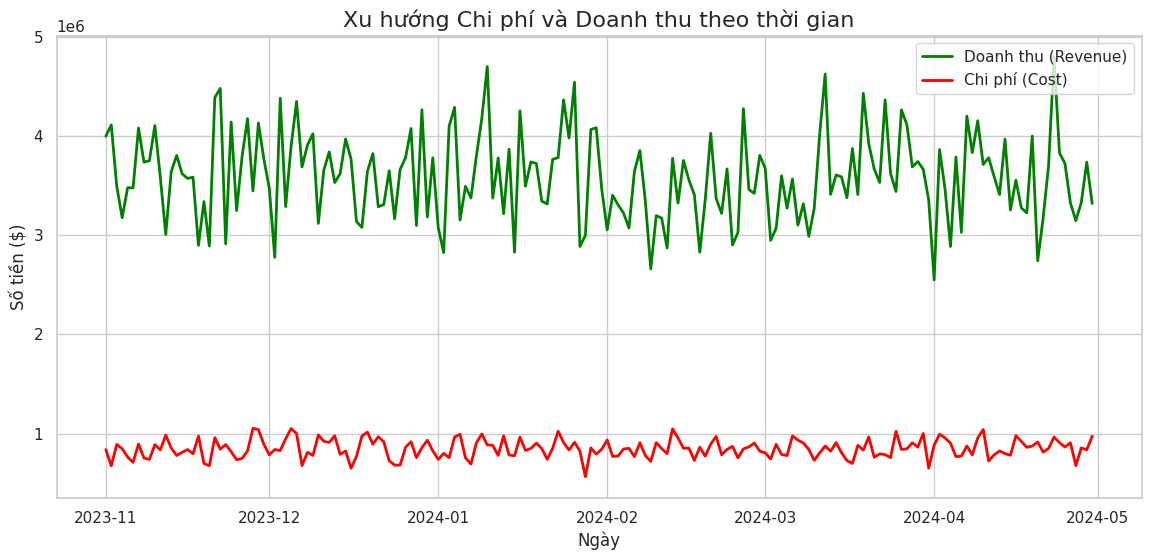

In [16]:
# Chuyển cột date về định dạng thời gian chuẩn để vẽ biểu đồ
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Tính tổng Doanh thu và Chi phí theo ngày
daily_trend = df_raw.groupby('date')[['cost', 'revenue']].sum()

# Vẽ biểu đồ Line Chart
plt.figure(figsize=(14, 6))
plt.plot(daily_trend.index, daily_trend['revenue'], label='Doanh thu (Revenue)', color='green', linewidth=2)
plt.plot(daily_trend.index, daily_trend['cost'], label='Chi phí (Cost)', color='red', linewidth=2)

plt.title('Xu hướng Chi phí và Doanh thu theo thời gian', fontsize=16)
plt.xlabel('Ngày')
plt.ylabel('Số tiền ($)')
plt.legend()
plt.grid(True)
plt.show()

## PHẦN II: CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH DỰ BÁO DOANH THU

**Mục tiêu:** Xây dựng mô hình dự báo doanh thu cho các chiến dịch tương lai dựa trên ngân sách (Cost), Kênh (Channel), Chiến dịch (Campaign) và Thời gian (Date). 

Dựa trên hướng dẫn thực hành, quy trình chuẩn bị bao gồm các bước sau:

### Bước 1: Lựa chọn đặc trưng (Feature Selection) & Ngăn chặn Rò rỉ dữ liệu (Data Leakage)
Tại thời điểm lên kế hoạch chạy quảng cáo, chúng ta không thể biết trước số lượt hiển thị, click hay tỷ lệ chuyển đổi. Nếu đưa các biến phái sinh này vào tập huấn luyện, mô hình sẽ gặp lỗi rò rỉ dữ liệu (Data Leakage) và mất đi khả năng dự báo tương lai. Do đó, cần loại bỏ toàn bộ các biến là "kết quả" của chiến dịch.

In [17]:
# Danh sách các cột gây rò rỉ dữ liệu cần loại bỏ
columns_to_drop = [
    'impressions', 'clicks', 'conversions',  # Các chỉ số tương tác (chưa biết trước)
    'cpc', 'cpa', 'ctr', 'conversion_rate',  # Các tỷ lệ phái sinh
    'roas', 'roi', 'profit_margin'           # Các chỉ số hiệu quả tài chính
]

# Tạo DataFrame mới dùng cho mô hình
df_model = df_raw.drop(columns=columns_to_drop)

print("Các cột được giữ lại cho mô hình (Đầu vào X và Mục tiêu y):")
print(df_model.columns.tolist())

Các cột được giữ lại cho mô hình (Đầu vào X và Mục tiêu y):
['date', 'channel', 'campaign', 'cost', 'revenue']


### Bước 2: Làm sạch dữ liệu (Data Cleaning)
Kiểm tra và xử lý các giá trị thiếu (Missing values) hoặc dòng dữ liệu trùng lặp (Duplicated rows).

In [18]:
print("Số lượng giá trị thiếu (Null):")
print(df_model.isnull().sum())

print(f"\nSố dòng bị trùng lặp: {df_model.duplicated().sum()}")

# Thực hiện xóa (nếu có)
df_model = df_model.dropna()
df_model = df_model.drop_duplicates()

Số lượng giá trị thiếu (Null):
date        0
channel     0
campaign    0
cost        0
revenue     0
dtype: int64

Số dòng bị trùng lặp: 0


### Bước 3: Trích xuất đặc trưng (Feature Engineering) cho Dữ liệu Thời gian
Mô hình Machine Learning không hiểu định dạng ngày tháng. Chúng ta cần trích xuất các thành phần có ý nghĩa thống kê như Tháng, Thứ trong tuần, và đặc biệt là biến nhị phân "Có phải cuối tuần không?".

In [19]:
# Trích xuất thông tin thời gian
df_model['month'] = df_model['date'].dt.month
df_model['day_of_week'] = df_model['date'].dt.dayofweek # Thứ 2 là 0, Chủ nhật là 6

# Tạo biến cờ (flag): 1 nếu là cuối tuần (T7, CN), 0 nếu là ngày thường
df_model['is_weekend'] = df_model['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Xóa cột 'date' gốc
df_model = df_model.drop(columns=['date'])
display(df_model.head(3))

,channel,campaign,cost,revenue,month,day_of_week,is_weekend
0,Facebook,Best Sellers,27534.312122,136591.812961,11,2,0
1,Facebook,Exclusive Offers,28207.782609,142821.779453,11,2,0
2,Facebook,Flash Sale,28519.979928,217096.009055,11,2,0


### Bước 4: Xử lý Ngoại lệ (Outliers) bằng kỹ thuật Capping (Winsorization)

**Tại sao không XÓA (Drop) ngoại lệ?**
Trong các bộ dữ liệu thông thường, ngoại lệ thường bị coi là dữ liệu lỗi (nhập sai số, lỗi hệ thống) và bị xóa đi. Tuy nhiên, đối với dữ liệu Marketing, các điểm chi phí (`cost`) cao đột biến thường rơi vào các đợt Mega Sale (ví dụ: Black Friday, Lễ/Tết). 
Nếu chúng ta xóa bỏ các dòng này, mô hình sẽ vĩnh viễn không học được hành vi của thị trường trong các chiến dịch lớn. Nhưng nếu giữ nguyên, độ lớn của các con số này sẽ làm lệch trọng số của mô hình Hồi quy.

**Giải pháp: Kỹ thuật Capping (Giới hạn trần)**
Kỹ thuật Capping (hay còn gọi là Winsorization) giải quyết bài toán này bằng cách:
1. Giữ nguyên toàn bộ các dòng dữ liệu (để không mất thông tin về `channel`, `campaign`).
2. Xác định một "Ngưỡng trần" (Upper Bound) dựa trên quy tắc Khoảng Tứ phân vị (IQR).
3. Những chi phí nào vượt qua ngưỡng trần này sẽ được "ép" xuống bằng đúng giá trị trần.

**Công thức tính ngưỡng trần:**
* `IQR = Q3 (Mốc 75%) - Q1 (Mốc 25%)`
* `Upper Bound = Q3 + 1.5 * IQR`

--- A. ĐIỀU TRA VÀ PHÁT HIỆN NGOẠI LỆ ---


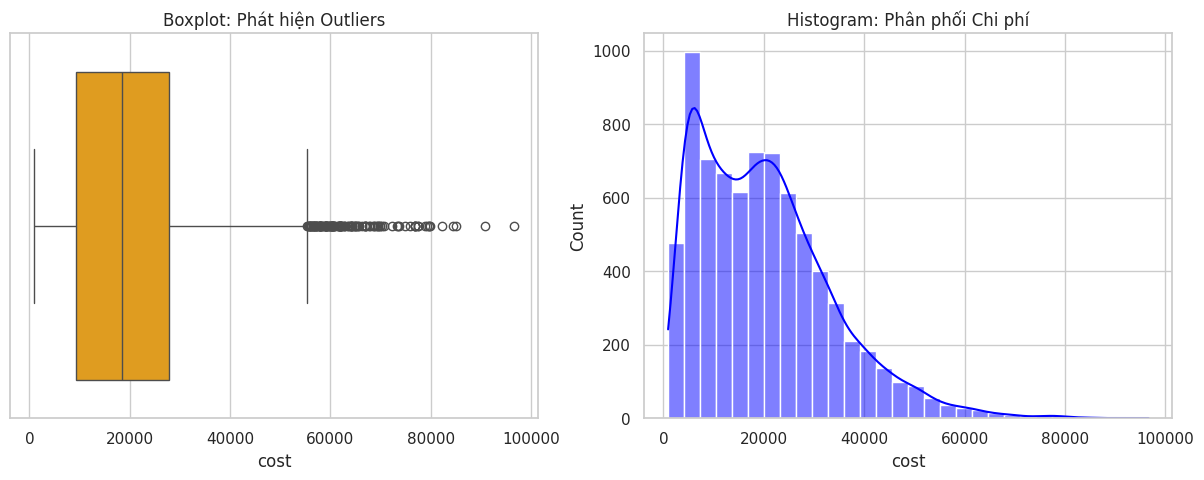

Giá trị Q1 (25%): 9298.73$
Giá trị Q3 (75%): 27735.24$
=> Ngưỡng trần (Upper Bound) được xác định là: 55390.01$

Số lượng bản ghi vượt ngưỡng trần: 128 dòng (chiếm 1.67% dữ liệu)
Xem thử 5 dòng Outliers có chi phí cao nhất:


,channel,campaign,cost,revenue,month,day_of_week,is_weekend
3332,Instagram,Best Sellers,96648.349664,138784.698772,2,2,0
3276,Instagram,Best Sellers,90878.094847,144785.067484,2,1,0
3439,Instagram,Flash Sale,85012.112262,328612.620018,3,3,0
2793,Instagram,Best Sellers,84499.251562,264830.682076,12,2,0
3703,Instagram,Best Sellers,82127.240524,353222.937433,4,6,1


In [20]:
import numpy as np

print("--- A. ĐIỀU TRA VÀ PHÁT HIỆN NGOẠI LỆ ---")

# 1. Vẽ biểu đồ phân phối trước khi xử lý (Boxplot & Histogram)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df_model['cost'], color='orange', ax=axes[0])
axes[0].set_title('Boxplot: Phát hiện Outliers', fontsize=12)

sns.histplot(df_model['cost'], bins=30, kde=True, color='blue', ax=axes[1])
axes[1].set_title('Histogram: Phân phối Chi phí', fontsize=12)
plt.show()

# 2. Tính toán các mốc tứ phân vị
Q1 = df_model['cost'].quantile(0.25)
Q3 = df_model['cost'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Giá trị Q1 (25%): {Q1:.2f}$")
print(f"Giá trị Q3 (75%): {Q3:.2f}$")
print(f"=> Ngưỡng trần (Upper Bound) được xác định là: {upper_bound:.2f}$")

# 3. Trích xuất các dòng là Outlier để phân tích
outliers_df = df_model[df_model['cost'] > upper_bound]
print(f"\nSố lượng bản ghi vượt ngưỡng trần: {len(outliers_df)} dòng (chiếm {(len(outliers_df)/len(df_model))*100:.2f}% dữ liệu)")
print("Xem thử 5 dòng Outliers có chi phí cao nhất:")
display(outliers_df.sort_values(by='cost', ascending=False).head())

--- B. THỰC THI CAPPING (GIỚI HẠN TRẦN) ---
- Đã xử lý Capping thành công!


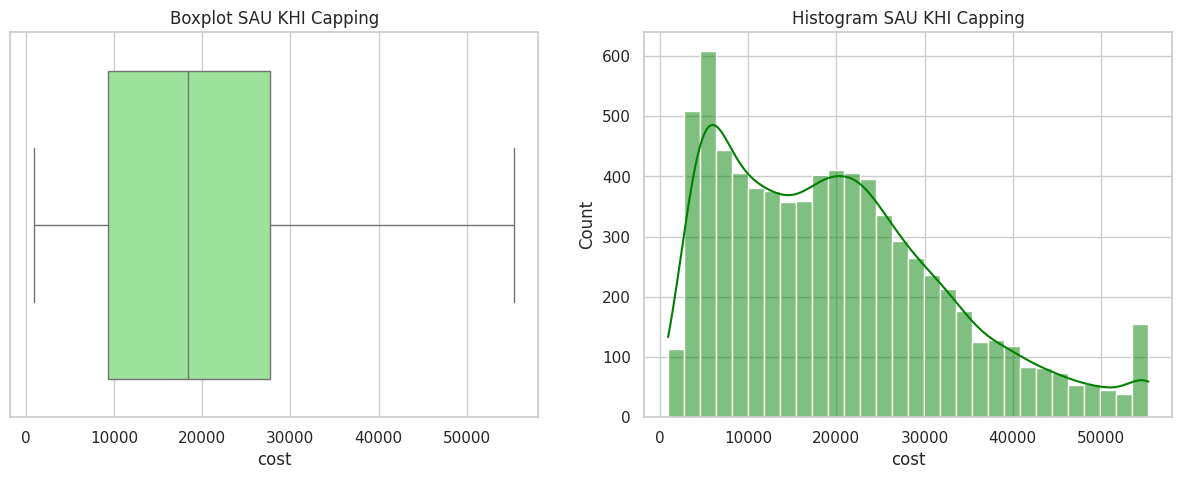

In [21]:
print("--- B. THỰC THI CAPPING (GIỚI HẠN TRẦN) ---")

# Sử dụng np.where để thay thế: Nếu cost > upper_bound thì gán bằng upper_bound, ngược lại giữ nguyên
df_model['cost_capped'] = np.where(df_model['cost'] > upper_bound, upper_bound, df_model['cost'])

# Xóa cột cost cũ và đổi tên cột mới thành cost
df_model = df_model.drop(columns=['cost'])
df_model = df_model.rename(columns={'cost_capped': 'cost'})

print("- Đã xử lý Capping thành công!")

# Vẽ lại biểu đồ để chứng minh Outliers đã được xử lý
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df_model['cost'], color='lightgreen', ax=axes[0])
axes[0].set_title('Boxplot SAU KHI Capping', fontsize=12)

sns.histplot(df_model['cost'], bins=30, kde=True, color='green', ax=axes[1])
axes[1].set_title('Histogram SAU KHI Capping', fontsize=12)
plt.show()

### Bước 5: Mã hóa dữ liệu định tính (One-Hot Encoding)
Biến đổi các thuộc tính dạng văn bản (`channel`, `campaign`) thành các cột nhị phân (0 và 1) để thuật toán có thể tính toán được.

In [22]:
# Dùng hàm get_dummies của Pandas để One-Hot Encoding
df_encoded = pd.get_dummies(df_model, columns=['channel', 'campaign'], drop_first=False)

print("Số lượng cột sau khi Mã hóa:", df_encoded.shape[1])

Số lượng cột sau khi Mã hóa: 18


### Bước 6: Chuẩn hóa dữ liệu (Standardization) và Lưu kết quả
Biến `cost` có giá trị rất lớn so với các biến còn lại (đang ở dạng 0, 1 hoặc số nhỏ). Cần dùng `StandardScaler` để đưa `cost` về cùng một thang đo (mean=0, std=1), giúp mô hình hội tụ tốt hơn.

*(Lưu ý: Không chuẩn hóa biến mục tiêu `revenue` để dễ dàng diễn dịch kết quả dự báo).*

*Về yêu cầu xử lý mất cân bằng dữ liệu: Kỹ thuật này chỉ áp dụng cho bài toán Phân loại (Classification). Vì đây là dự án Hồi quy (Regression) dự báo số liên tục, nên không cần thực hiện bước này.*

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Chuẩn hóa cột cost
df_encoded['cost_scaled'] = scaler.fit_transform(df_encoded[['cost']])

# Bỏ cột cost gốc
df_final = df_encoded.drop(columns=['cost'])

# Xắp xếp lại cột: Đưa revenue (Target) về cuối cùng cho dễ nhìn
cols = [c for c in df_final.columns if c != 'revenue'] + ['revenue']
df_final = df_final[cols]

# Kiểm tra dữ liệu hoàn thiện
print("--- DỮ LIỆU ĐÃ SẴN SÀNG CHO MÔ HÌNH HỌC MÁY ---")
display(df_final.head(3))

# Xuất file CSV cuối cùng
df_final.to_csv('../media_ml_ready.csv', index=False)
print("\nĐã xuất file: media_ml_ready.csv")

--- DỮ LIỆU ĐÃ SẴN SÀNG CHO MÔ HÌNH HỌC MÁY ---


,month,day_of_week,is_weekend,channel_Facebook,channel_Google Ads,channel_Instagram,channel_LinkedIn,channel_Twitter,channel_Website,campaign_Best Sellers,campaign_Exclusive Offers,campaign_Flash Sale,campaign_Limited Edition,campaign_Must-Haves,campaign_New Arrivals,campaign_Trending Now,cost_scaled,revenue
0,11,2,0,True,False,False,False,False,False,True,False,False,False,False,False,False,0.583142,136591.812961
1,11,2,0,True,False,False,False,False,False,False,True,False,False,False,False,False,0.635627,142821.779453
2,11,2,0,True,False,False,False,False,False,False,False,True,False,False,False,False,0.659957,217096.009055



Đã xuất file: media_ml_ready.csv
